# MLP vs QNN — Comparación

Este notebook carga los resultados precomputados de:
- `../classical/mlp_results.json`
- `../quantum/qnn_results.json`

y genera todas las gráficas de comparación y la tabla resumen.

**No se entrena ningún modelo aquí.** Se puede re-ejecutar libremente sin tocar los notebooks de entrenamiento.

Activa `COMPARE_4F = True` cuando los archivos de resultados de 4 características también estén disponibles.

## Importaciones

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Configuración

In [2]:
COMPARE_4F = True

MLP_FILE     = "../classical/mlp_results.json"
QNN_FILE     = "../quantum/qnn_results.json"
MLP_4F_FILE  = "../classical/mlp_results_4f.json"
QNN_4F_FILE  = "../quantum/qnn_results_4f.json"

for f in [MLP_FILE, QNN_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Missing results file: {f}\n"
            "Run mlp.ipynb and qnn.ipynb first."
        )

if COMPARE_4F:
    for f in [MLP_4F_FILE, QNN_4F_FILE]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing 4-feature results file: {f}")

print("Results files found — ready to compare.")

Results files found — ready to compare.


## Cargar Resultados

In [3]:
with open(MLP_FILE) as f:
    mlp = json.load(f)

with open(QNN_FILE) as f:
    qnn = json.load(f)

if COMPARE_4F:
    with open(MLP_4F_FILE) as f:
        mlp4 = json.load(f)
    with open(QNN_4F_FILE) as f:
        qnn4 = json.load(f)

print("MLP results:")
print(f"  Test accuracy  : {mlp['accuracy_test']:.4f}")
print(f"  Train time     : {mlp['train_time_s']:.4f} s")
print(f"  Parameters     : {mlp['n_parameters']}")
print(f"  Iterations run : {mlp['n_iter']}")
print()
print("QNN results:")
print(f"  Test accuracy (sim)  : {qnn['accuracy_test_sim']:.4f}")
if qnn.get('real_hw_run'):
    print(f"  Test accuracy (real) : {qnn['accuracy_test_real']:.4f}")
print(f"  Train time (sim)     : {qnn['train_time_sim_s']:.2f} s")
print(f"  Parameters           : {qnn['n_parameters']}")

MLP results:
  Test accuracy  : 0.8000
  Train time     : 0.1233 s
  Parameters     : 37
  Iterations run : 500

QNN results:
  Test accuracy (sim)  : 0.8000
  Test accuracy (real) : 0.7500
  Train time (sim)     : 5.09 s
  Parameters           : 6


## Gráfica 1 — Comparación de Precisión

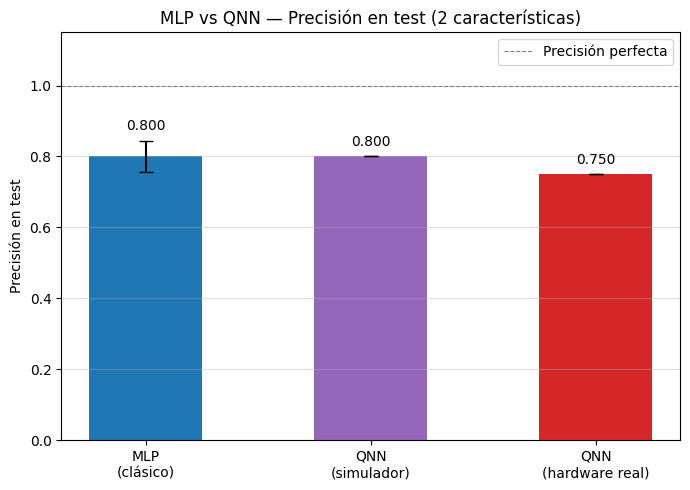

In [4]:
labels = ["MLP\n(clásico)", "QNN\n(simulador)"]
values = [mlp["accuracy_test"], qnn["accuracy_test_sim"]]
colors = ["tab:blue", "tab:purple"]
yerr   = [mlp["cv_std"], 0]

if qnn.get("real_hw_run") and qnn.get("accuracy_test_real") is not None:
    labels.append("QNN\n(hardware real)")
    values.append(qnn["accuracy_test_real"])
    colors.append("tab:red")
    yerr.append(0)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x, values, color=colors, width=0.5,
              yerr=yerr, capsize=5, error_kw={"elinewidth": 1.5})

for bar, val, err in zip(bars, values, yerr):
    ax.text(bar.get_x() + bar.get_width() / 2, val + err + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Precisión en test")
ax.set_title(f"MLP vs QNN — Precisión en test ({mlp['n_features']} características)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Precisión perfecta")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot1_accuracy.png", dpi=150)
plt.show()

## Gráfica 2 — Tiempo de Entrenamiento

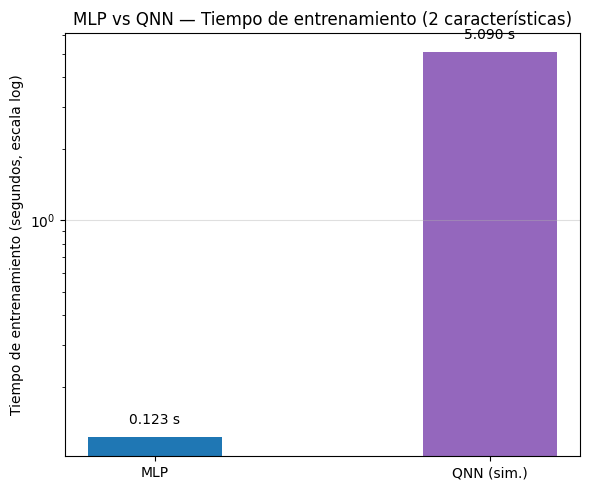

In [5]:
t_labels = ["MLP", "QNN (sim.)"]
t_values = [mlp["train_time_s"], qnn["train_time_sim_s"]]
t_colors = ["tab:blue", "tab:purple"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(t_labels, t_values, color=t_colors, width=0.4)
for bar, val in zip(bars, t_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.1,
            f"{val:.3f} s", ha="center", va="bottom", fontsize=10)

ax.set_yscale("log")
ax.set_ylabel("Tiempo de entrenamiento (segundos, escala log)")
ax.set_title(f"MLP vs QNN — Tiempo de entrenamiento ({mlp['n_features']} características)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot2_training_time.png", dpi=150)
plt.show()

## Gráfica 3 — Curvas de Pérdida Comparadas

Esta gráfica es exclusiva de este experimento: ambos modelos tienen curva de pérdida, por lo que
se puede comparar visualmente la velocidad de convergencia. Nótese que las escalas de pérdida **no son comparables**:
el MLP usa log-loss estándar (entropía cruzada, siempre ≥ 0), mientras que la QNN usa
la variante de entropía cruzada de qiskit-ml sobre valores de expectación en [−1, +1],
que produce valores negativos — más negativo significa mejor.

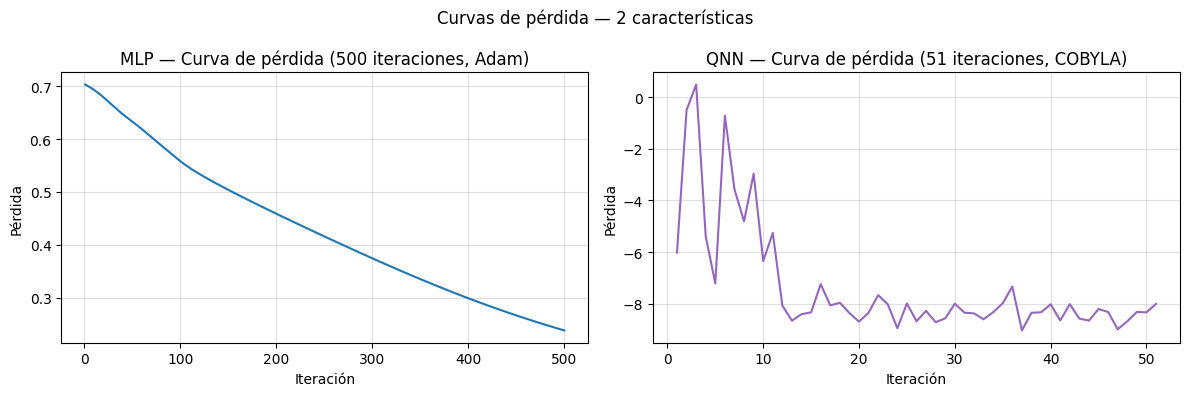

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(mlp["loss_curve"]) + 1), mlp["loss_curve"], color="tab:blue")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Pérdida")
axes[0].set_title(f"MLP — Curva de pérdida ({mlp['n_iter']} iteraciones, Adam)")
axes[0].grid(True, alpha=0.4)

axes[1].plot(range(1, len(qnn["loss_history"]) + 1), qnn["loss_history"], color="tab:purple")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Pérdida")
axes[1].set_title(f"QNN — Curva de pérdida ({len(qnn['loss_history'])} iteraciones, {qnn['optimizer']})")
axes[1].grid(True, alpha=0.4)

plt.suptitle(f"Curvas de pérdida — {mlp['n_features']} características")
plt.tight_layout()
plt.savefig("plot3_loss_curves.png", dpi=150)
plt.show()

## Gráfica 4 — Parámetros Entrenables vs Precisión

Pone la complejidad del modelo en contexto: cuánta precisión alcanza cada modelo
por parámetro entrenable.

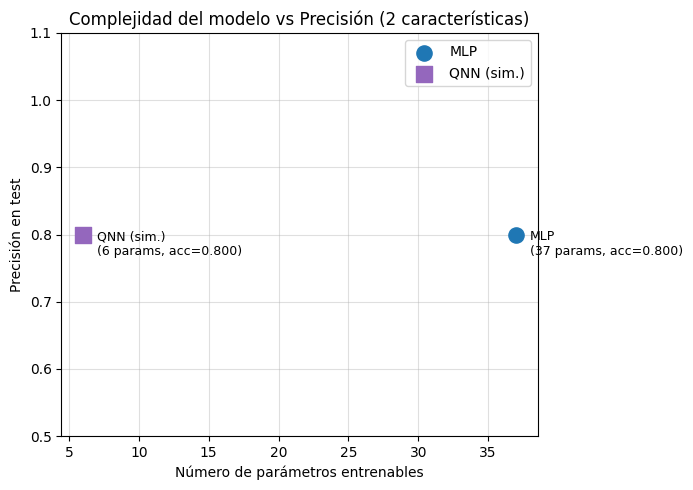

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

models  = ["MLP", "QNN (sim.)"]
params  = [mlp["n_parameters"], qnn["n_parameters"]]
accs    = [mlp["accuracy_test"], qnn["accuracy_test_sim"]]
colors  = ["tab:blue", "tab:purple"]
markers = ["o", "s"]

for name, p, a, c, m in zip(models, params, accs, colors, markers):
    ax.scatter(p, a, color=c, marker=m, s=120, zorder=3, label=name)
    ax.annotate(f"{name}\n({p} params, acc={a:.3f})",
                xy=(p, a), xytext=(10, -15), textcoords="offset points", fontsize=9)

ax.set_xlabel("Número de parámetros entrenables")
ax.set_ylabel("Precisión en test")
ax.set_ylim(0.5, 1.1)
ax.set_title(f"Complejidad del modelo vs Precisión ({mlp['n_features']} características)")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("plot4_params_vs_accuracy.png", dpi=150)
plt.show()

## Gráfica 5 — Matrices de Confusión

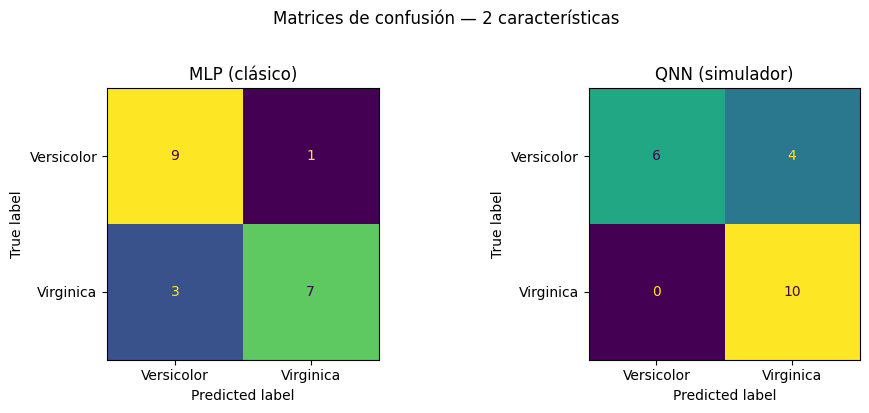

In [8]:
cm_mlp = confusion_matrix(mlp["y_test"], mlp["y_pred_test"])
cm_qnn = confusion_matrix(qnn["y_test"], qnn["y_pred_test_sim"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes,
                          [cm_mlp, cm_qnn],
                          ["MLP (clásico)", "QNN (simulador)"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Versicolor", "Virginica"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f"Matrices de confusión — {mlp['n_features']} características", y=1.02)
plt.tight_layout()
plt.savefig("plot5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfica 6 — Comparación 2 vs 4 Características (opcional)

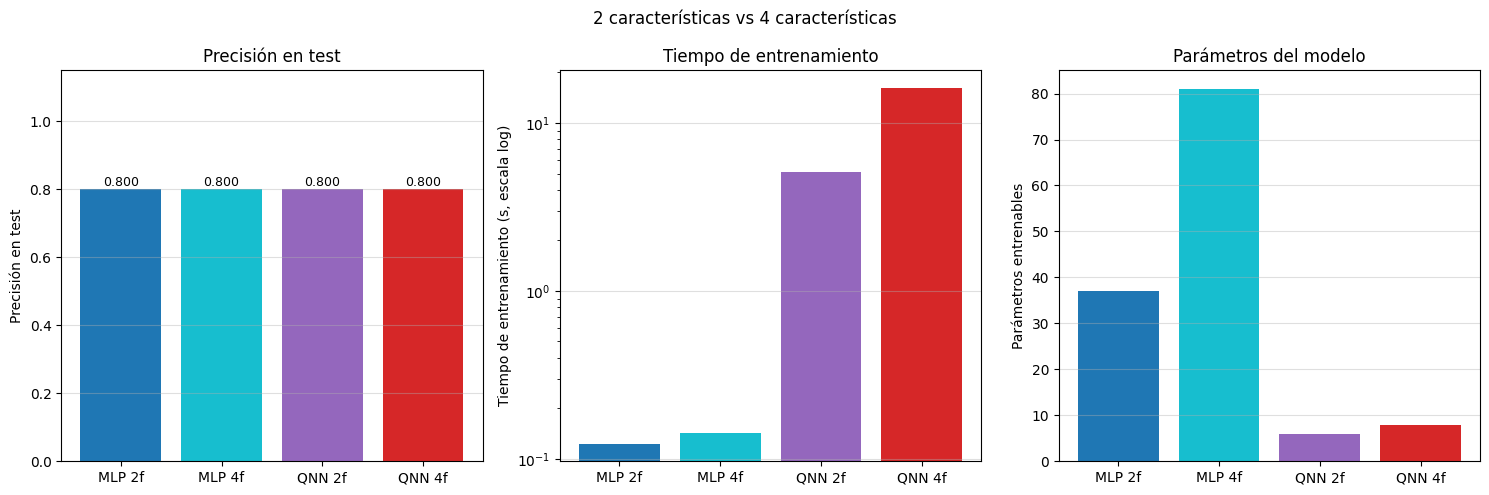

In [9]:
if COMPARE_4F:
    experiments = [
        ("MLP 2f",  mlp["accuracy_test"],      mlp["train_time_s"],      mlp["n_parameters"],  "tab:blue"),
        ("MLP 4f",  mlp4["accuracy_test"],     mlp4["train_time_s"],     mlp4["n_parameters"], "tab:cyan"),
        ("QNN 2f",  qnn["accuracy_test_sim"],  qnn["train_time_sim_s"],  qnn["n_parameters"],  "tab:purple"),
        ("QNN 4f",  qnn4["accuracy_test_sim"], qnn4["train_time_sim_s"], qnn4["n_parameters"], "tab:red"),
    ]

    names  = [e[0] for e in experiments]
    accs   = [e[1] for e in experiments]
    times  = [e[2] for e in experiments]
    params = [e[3] for e in experiments]
    colors = [e[4] for e in experiments]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].bar(names, accs, color=colors)
    for i, val in enumerate(accs):
        axes[0].text(i, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
    axes[0].set_ylim(0, 1.15)
    axes[0].set_ylabel("Precisión en test")
    axes[0].set_title("Precisión en test")
    axes[0].grid(axis="y", alpha=0.4)

    axes[1].bar(names, times, color=colors)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Tiempo de entrenamiento (s, escala log)")
    axes[1].set_title("Tiempo de entrenamiento")
    axes[1].grid(axis="y", alpha=0.4)

    axes[2].bar(names, params, color=colors)
    axes[2].set_ylabel("Parámetros entrenables")
    axes[2].set_title("Parámetros del modelo")
    axes[2].grid(axis="y", alpha=0.4)

    plt.suptitle("2 características vs 4 características")
    plt.tight_layout()
    plt.savefig("plot6_2f_vs_4f.png", dpi=150)
    plt.show()
else:
    print("COMPARE_4F is False — skipping 2f vs 4f comparison.")
    print("Set COMPARE_4F = True once both 4-feature result files are available.")

## Tabla Resumen

In [10]:
summary = {
    "n_features"                 : mlp["n_features"],
    "n_train"                    : mlp["n_train"],
    "n_test"                     : mlp["n_test"],
    # MLP
    "mlp_accuracy_test"          : mlp["accuracy_test"],
    "mlp_accuracy_train"         : mlp["accuracy_train"],
    "mlp_cv_mean"                : mlp["cv_mean"],
    "mlp_cv_std"                 : mlp["cv_std"],
    "mlp_train_time_s"           : mlp["train_time_s"],
    "mlp_n_parameters"           : mlp["n_parameters"],
    "mlp_n_iter"                 : mlp["n_iter"],
    "mlp_hidden_layers"          : mlp["hidden_layers"],
    "mlp_optimizer"              : mlp["optimizer"],
    # QNN
    "qnn_accuracy_test_sim"      : qnn["accuracy_test_sim"],
    "qnn_accuracy_train_sim"     : qnn["accuracy_train_sim"],
    "qnn_accuracy_test_real"     : qnn.get("accuracy_test_real"),
    "qnn_train_time_sim_s"       : qnn["train_time_sim_s"],
    "qnn_n_parameters"           : qnn["n_parameters"],
    "qnn_n_qubits"               : qnn["n_qubits"],
    "qnn_feature_map"            : qnn["feature_map"],
    "qnn_ansatz"                 : qnn["ansatz"],
    "qnn_observable"             : qnn["observable"],
    "qnn_optimizer"              : qnn["optimizer"],
    "qnn_loss"                   : qnn["loss"],
    "qnn_final_loss"             : qnn["loss_history"][-1],
    "qnn_real_hw_run"            : qnn.get("real_hw_run", False),
    "qnn_backend"                : qnn.get("backend_name"),
}

if COMPARE_4F:
    summary["mlp_4f_accuracy_test"]     = mlp4["accuracy_test"]
    summary["mlp_4f_train_time_s"]      = mlp4["train_time_s"]
    summary["mlp_4f_n_parameters"]      = mlp4["n_parameters"]
    summary["qnn_4f_accuracy_test_sim"] = qnn4["accuracy_test_sim"]
    summary["qnn_4f_train_time_sim_s"]  = qnn4["train_time_sim_s"]
    summary["qnn_4f_n_parameters"]      = qnn4["n_parameters"]

with open("comparison_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Print as readable table
col_w = 36
print(f"{'Metric':<{col_w}} {'MLP':>14} {'QNN (sim)':>14} {'QNN (real)':>14}")
print("-" * (col_w + 46))

rows = [
    ("Test accuracy",
     f"{mlp['accuracy_test']:.4f}",
     f"{qnn['accuracy_test_sim']:.4f}",
     f"{qnn['accuracy_test_real']:.4f}" if qnn.get('accuracy_test_real') else "N/A"),
    ("Train accuracy",
     f"{mlp['accuracy_train']:.4f}",
     f"{qnn['accuracy_train_sim']:.4f}",
     "N/A"),
    ("CV mean ± std",
     f"{mlp['cv_mean']:.4f} ± {mlp['cv_std']:.4f}",
     "N/A",
     "N/A"),
    ("Train time (s)",
     f"{mlp['train_time_s']:.4f}",
     f"{qnn['train_time_sim_s']:.2f}",
     "N/A"),
    ("Trainable parameters",
     str(mlp['n_parameters']),
     str(qnn['n_parameters']),
     "—"),
    ("Iterations run",
     str(mlp['n_iter']),
     str(len(qnn['loss_history'])),
     "—"),
    ("Final loss (⚠ different scales)",
     f"{mlp['loss_curve'][-1]:.4f}",
     f"{qnn['loss_history'][-1]:.4f}",
     "—"),
]

for label, m, q, r in rows:
    print(f"{label:<{col_w}} {m:>14} {q:>14} {r:>14}")

print()
print("Note: MLP loss is standard log-loss (>= 0); QNN loss is qiskit-ml's")
print("cross-entropy over expectation values in [-1, +1] — scales are not comparable.")
print()
print("Summary saved to comparison_summary.json")

Metric                                          MLP      QNN (sim)     QNN (real)
----------------------------------------------------------------------------------
Test accuracy                                0.8000         0.8000         0.7500
Train accuracy                               0.9750         0.7875            N/A
CV mean ± std                        0.9500 ± 0.0447            N/A            N/A
Train time (s)                               0.1233           5.09            N/A
Trainable parameters                             37              6              —
Iterations run                                  500             51              —
Final loss (⚠ different scales)              0.2379        -8.0056              —

Note: MLP loss is standard log-loss (>= 0); QNN loss is qiskit-ml's
cross-entropy over expectation values in [-1, +1] — scales are not comparable.

Summary saved to comparison_summary.json
